# MILESTONE - 2

### Week - 3 : Feature Engineering and Selection

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the encoded and cleaned dataset
df = pd.read_csv("Wednesday_Encoded.csv")

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (610794, 72)


In [5]:
print("Unique labels:", df['Label'].unique())

Unique labels: [0 4 3 2 1 5]


<b>Step - 1 : Correlation Analysis for Dimensionality Reduction</b>

Correlation with target:
 Label                    1.000000
Fwd IAT Max              0.747350
Flow IAT Max             0.747040
Idle Max                 0.746524
Fwd IAT Std              0.738187
                           ...   
Bwd Packet Length Min   -0.362090
Bwd PSH Flags                 NaN
Fwd URG Flags                 NaN
Bwd URG Flags                 NaN
CWE Flag Count                NaN
Name: Label, Length: 72, dtype: float64


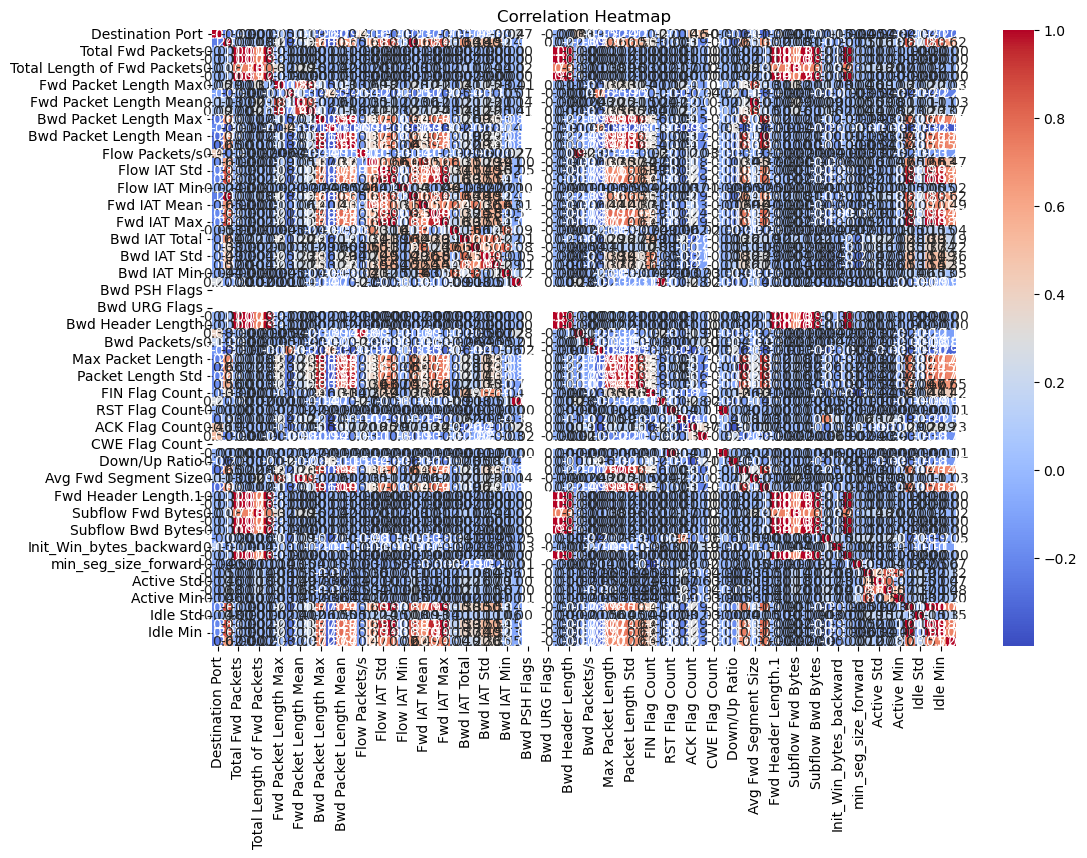

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation with target
corr_matrix = df.corr()
target_corr = corr_matrix['Label'].sort_values(ascending=False)  # replace 'target_column'

print("Correlation with target:\n", target_corr)

# Heatmap of all numerical features
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


A correlation heatmap was plotted to understand the relationships between numerical features and the target variable. This helps identify which features are most strongly associated with attack detection.

In [7]:
# Select only numeric columns (including encoded 'Label')
numeric_df = df.select_dtypes(include=['int64','float64'])

df.columns = df.columns.str.strip()

# Compute correlation only on numeric columns
if 'Label' in numeric_df.columns:
    corr_matrix = numeric_df.corr()
    target_corr = corr_matrix['Label'].sort_values(ascending=False)

    # Identify important vs non-important features
    important_features = target_corr[abs(target_corr) > 0.3].index.tolist()
    non_important_features = target_corr[abs(target_corr) <= 0.3].index.tolist()

    print("Important Features:\n", important_features)
    print("\nNon-Important Features:\n", non_important_features)
else:
    print("Column 'Label' not found in numeric data.")


Important Features:
 ['Label', 'Fwd IAT Max', 'Flow IAT Max', 'Idle Max', 'Fwd IAT Std', 'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Min', 'Bwd Packet Length Max', 'Packet Length Std', 'Flow IAT Std', 'Bwd Packet Length Std', 'Packet Length Mean', 'Max Packet Length', 'Average Packet Size', 'Packet Length Variance', 'Fwd IAT Total', 'Flow Duration', 'Fwd IAT Mean', 'Flow IAT Mean', 'FIN Flag Count', 'Bwd IAT Std', 'Bwd IAT Max', 'Min Packet Length', 'Bwd Packet Length Min']

Non-Important Features:
 ['ACK Flag Count', 'Bwd IAT Mean', 'Bwd IAT Total', 'Idle Std', 'Active Mean', 'Active Min', 'Active Max', 'Fwd Packet Length Std', 'min_seg_size_forward', 'Active Std', 'Bwd IAT Min', 'Fwd IAT Min', 'Fwd Packet Length Max', 'Flow IAT Min', 'Fwd Header Length.1', 'Fwd Header Length', 'Subflow Bwd Bytes', 'Total Length of Bwd Packets', 'Bwd Header Length', 'Subflow Fwd Packets', 'Total Fwd Packets', 'Total Backward Packets', 'Subflow Bwd Packets', 'act_data_pkt_fwd',

<b>Step - 2 : PCA Analysis</b>

Principal Component Analysis (PCA) was applied to reduce the dataset’s dimensionality while retaining the most significant variance. It helps in identifying the key components influencing attack detection.

In [8]:
# Drop non-important features
df_filtered = df[important_features]
print("Shape after dropping non-important features: ",df_filtered.shape)

Shape after dropping non-important features:  (610794, 26)


In [9]:
# Features (X) and target (y)
X = df_filtered.drop(columns=['Label'])
y = df_filtered[['Label']]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (610794, 25)
Target shape: (610794, 1)


In [10]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
from sklearn.decomposition import PCA

# Fit PCA on scaled data
pca = PCA(n_components=10)  # Keep all components for full analysis
X_pca = pca.fit_transform(X_scaled)

In [12]:
print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (610794, 25)
Shape after PCA: (610794, 10)


In [13]:
explained_variance = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_))],
    'Explained_Variance': pca.explained_variance_ratio_
}).sort_values(by='Explained_Variance', ascending=False)

# Display top 10 PCA components
top_10_pca = explained_variance.head(10)
print("Top 10 PCA Components based on explained variance:")
print(top_10_pca)

Top 10 PCA Components based on explained variance:
     PC  Explained_Variance
0   PC1            0.668631
1   PC2            0.110992
2   PC3            0.065889
3   PC4            0.054784
4   PC5            0.027728
5   PC6            0.017174
6   PC7            0.015531
7   PC8            0.011802
8   PC9            0.011021
9  PC10            0.005732


<b>Step - 3 : Analyze Feature Importance</b>

In [14]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
# Initialize Random Forest with 50 trees as suggested
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [16]:
X.columns

Index(['Fwd IAT Max', 'Flow IAT Max', 'Idle Max', 'Fwd IAT Std',
       'Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Idle Mean',
       'Idle Min', 'Bwd Packet Length Max', 'Packet Length Std',
       'Flow IAT Std', 'Bwd Packet Length Std', 'Packet Length Mean',
       'Max Packet Length', 'Average Packet Size', 'Packet Length Variance',
       'Fwd IAT Total', 'Flow Duration', 'Fwd IAT Mean', 'Flow IAT Mean',
       'FIN Flag Count', 'Bwd IAT Std', 'Bwd IAT Max', 'Min Packet Length',
       'Bwd Packet Length Min'],
      dtype='object')

In [17]:
# Extract feature importance
importances = rf.feature_importances_

# Create a DataFrame to visualize importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
top_10_features = feature_importance_df.head(10)
print("Top 10 Features contributing to attacks:")
print(top_10_features)


Top 10 Features contributing to attacks:
                   Feature  Importance
4   Bwd Packet Length Mean    0.128077
9        Packet Length Std    0.107541
8    Bwd Packet Length Max    0.105197
11   Bwd Packet Length Std    0.081113
5     Avg Bwd Segment Size    0.069998
15  Packet Length Variance    0.069013
13       Max Packet Length    0.062298
1             Flow IAT Max    0.054253
12      Packet Length Mean    0.053169
14     Average Packet Size    0.044839


I have identified the top 10 most significant features contributing to network attacks by analyzing feature importance using the Random Forest algorithm.

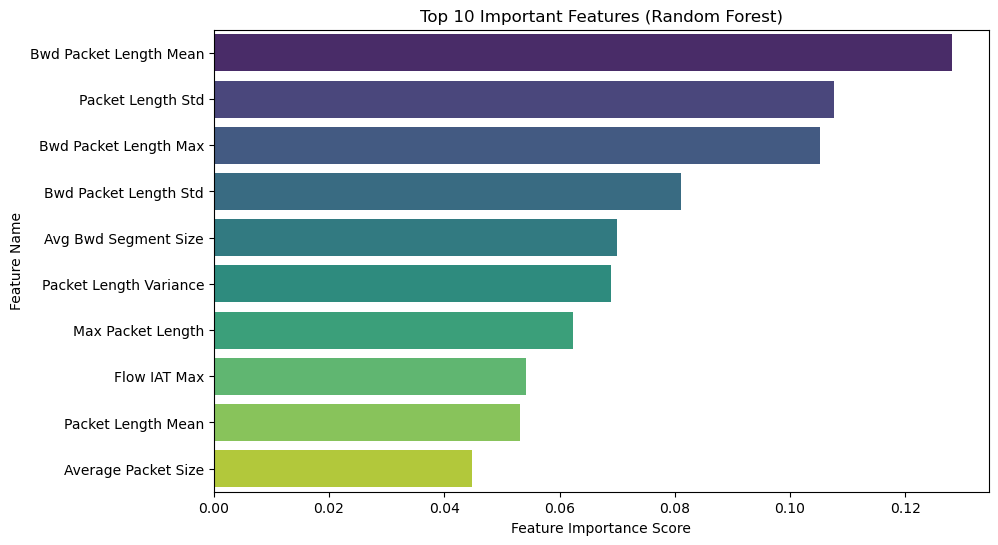

In [18]:
# Visualize top 10 most important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.show()

I visualized the top 10 most important features identified by the Random Forest model.
This bar plot highlights which features contribute the most to predicting attack behavior.

In [19]:
# Select top 10 features
top_features = top_10_features['Feature'].tolist()

# Include the label column
selected_columns = top_features + ['Label']

# Create a new DataFrame with selected columns
top_features_df = df_filtered[selected_columns]

# Save to CSV file
top_features_df.to_csv("top10_features_dataset.csv", index=False)

print("Top 10 feature dataset saved as 'top10_features_dataset.csv'")


Top 10 feature dataset saved as 'top10_features_dataset.csv'


### Week - 4 : Supervised Model Training

<b>Step - 1 & 2 : Train models such as Random Forest, SVM, or Logistic Regression & Evaluate accuracy, precision, recall, and F1-score.</b>

In [20]:
import pandas as pd
# Load the saved dataset containing top 10 important features and the label
df = pd.read_csv("top10_features_dataset.csv")

In [21]:
df.head()

,Bwd Packet Length Mean,Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Std,Avg Bwd Segment Size,Packet Length Variance,Max Packet Length,Flow IAT Max,Packet Length Mean,Average Packet Size,Label
0,6.000000,0.000000,6,0.000000,6.000000,0.000000,6,38308,6.000000,9.000000,0
1,65.200000,56.529599,163,89.278777,65.200000,3195.595588,163,73,29.294118,31.125000,0
2,525.000000,671.751541,1575,813.326503,525.000000,451250.132400,1575,810,370.588235,393.750000,0
3,555.000000,704.654082,3069,977.480342,555.000000,496537.374700,3069,13391,337.066667,348.689655,0
4,525.333333,704.585067,1576,813.842901,525.333333,496440.116700,1576,794,393.875000,420.133333,0


In [22]:
print("Shape:", df.shape)

Shape: (610794, 11)


In [23]:
# Separate independent variables (features) and dependent variable (label)
X = df.drop(columns=['Label'])
y = df[['Label']]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (610794, 10)
Target vector shape: (610794, 1)


In [24]:
from sklearn.model_selection import train_test_split
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (488635, 10)
Testing data shape: (122159, 10)


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<b>(i) Random Forest</b>

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their results to improve prediction accuracy and reduce overfitting.

Key Points:

Works by taking the majority vote from several decision trees.

Handles large and complex datasets effectively.

Reduces variance and improves model stability.
.
Provides feature importance for better feature selection.

In [26]:
from sklearn.ensemble import RandomForestClassifier
# Initialize and train Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=50,     # fewer trees
    max_depth=8,         # limit tree depth
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=50, random_state=42)

In [27]:
# Predict on test data
y_pred_rf = rf.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Evaluate Random Forest model performance
print("=== Random Forest Evaluation ===")
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, y_pred_rf)

print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy: {test_acc}")

print("\nPrecision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

=== Random Forest Evaluation ===
Training Accuracy: 0.9810819937171917
Testing Accuracy: 0.9814504048003012

Precision: 0.9817585848707339
Recall: 0.9814504048003012
F1 Score: 0.9810802355340912


<b>(ii) Support Vector Machine (SVM)</b>

SVM is a supervised learning algorithm used for classification and regression that finds the optimal hyperplane to separate data points of different classes.

Key Points:

Works well for high-dimensional data.

Effective in cases where classes are clearly separable.

Uses kernel functions to handle non-linear classification.

Sensitive to feature scaling and parameter tuning.

In [29]:
from sklearn.svm import SVC

In [30]:
# Initialize and train Support Vector Machine classifier
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [31]:
# Predict on test data
y_pred_svm = svm.predict(X_test_scaled)

In [32]:
# Evaluate SVM model performance
print("=== SVM Evaluation ===")
train_acc = accuracy_score(y_train, svm.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred_svm)

print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy: {test_acc}")
print("\nPrecision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

=== SVM Evaluation ===
Training Accuracy: 0.9580893714121993
Testing Accuracy: 0.9591270393503548

Precision: 0.9608053042811455
Recall: 0.9591270393503548
F1 Score: 0.958351070344578


<b>(iii) Logistic Regression </b>

Logistic Regression is a supervised machine learning algorithm used for binary and multiclass classification that predicts the probability of a data point belonging to a particular class.

Key Points:

Based on the sigmoid (logistic) function to map outputs between 0 and 1.

Simple, fast, and interpretable model.

Works best with linearly separable data.

Requires feature scaling for better performance.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [34]:
# Cell 2: Initialize and train the Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [35]:
y_pred_lr = lr.predict(X_test_scaled)

In [36]:
print("=== Logistic Regression Evaluation ===")
train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred_lr)

print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy: {test_acc}")
print("\nPrecision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

=== Logistic Regression Evaluation ===
Training Accuracy: 0.9467414327667891
Testing Accuracy: 0.947650193600144

Precision: 0.9454043416936698
Recall   : 0.947650193600144
F1 Score : 0.9431681618281668


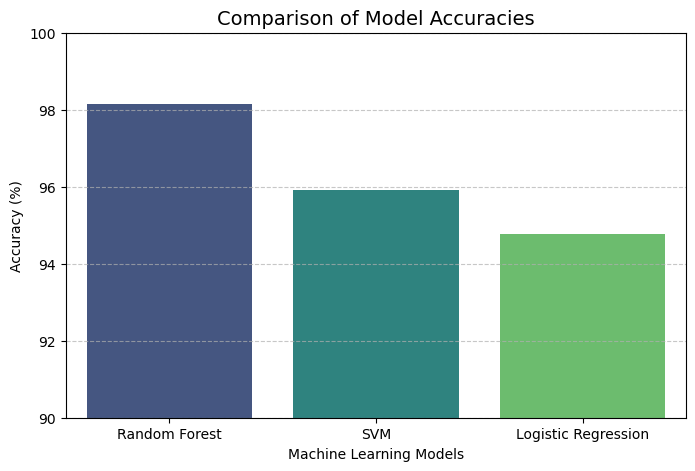

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model accuracies
data = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Accuracy': [98.14, 95.91, 94.76]  # use your actual accuracy values
}

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=df, palette='viridis')
plt.title('Comparison of Model Accuracies', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xlabel('Machine Learning Models')
plt.ylim(90, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


🧩 Interpretation

The Random Forest model achieved the highest accuracy among all tested models.

SVM and Logistic Regression also performed well, showing strong generalization on the test data.

This comparison helps visualize the effectiveness of ensemble methods (like Random Forest) over simpler linear models.

In [38]:
import joblib

# Save trained models
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(lr, 'logistic_regression_model.pkl')


['logistic_regression_model.pkl']